In [320]:
import os
import argparse
import numpy as np
import matplotlib.pyplot as plt
import mvn #hay que importar este por que tiene datos de los segments y joints y angles
from load_mvnx import load_mvnx
from scipy.signal import butter, filtfilt
from scipy import signal
import matplotlib.pyplot as plt
import matplotlib as mpl
import scipy.io as sio
from scipy.interpolate import interp1d


mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['font.size'] = 10
#Este file lo que hace es obtener con 4 DOF
# , mas el tiempo los joints.mot para despues meterlos a open sim
#el environment en el que esta matplotlib es 3.13.5 (base)
file_name = r"C:/Users/adria/Downloads/Python-IMU/Adriana-Neuroengineering_lab/20260525/test_04.mvnx"
mat = sio.loadmat( r"C:/Users/adria/Downloads/Python-IMU/Adriana-Neuroengineering_lab/20260525/EMG_matlab/20260525_subject_01_cond_ASS-PRE-EXT-RIGHT_run_04_ecr_fcr_final.mat")  # cambia el nombre si hace falta




Frame rate: 60 Hz
vector shape: (5230,)
primeros valores: [9.937804 9.955851 9.973898 9.984988 9.983157 9.97437  9.969566 9.975984
 9.986385 9.989989]


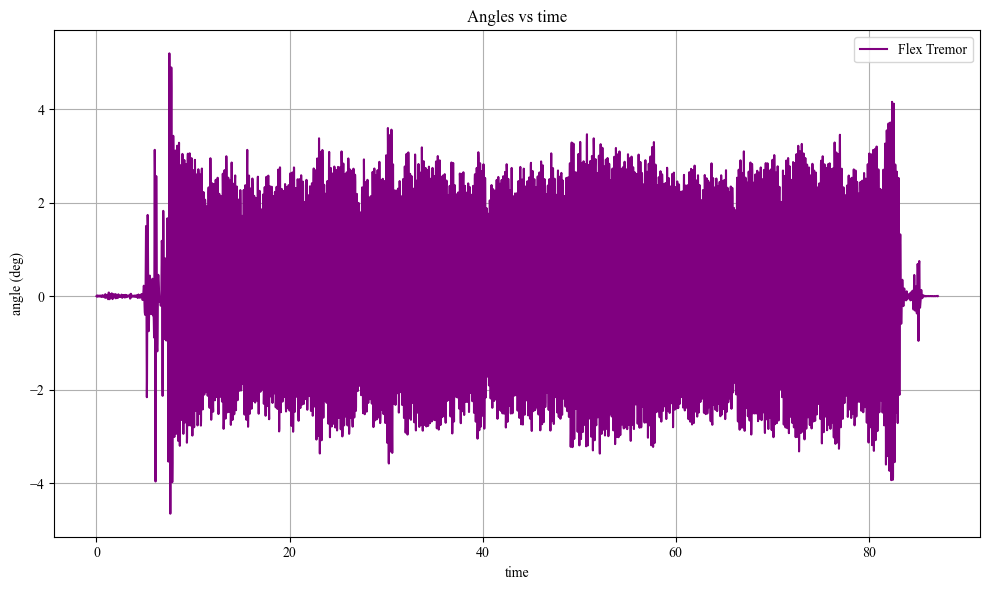

<function len(obj, /)>

In [321]:

def butter_bandpass_filter(data, lowcut, highcut, fs, order=3):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='bandpass')
    #  angles_fil_values = signal.filtfilt(b, a, angles.values, padtype = 'odd', padlen=3*(max(len(b),len(a))-1), axis=0)
    return filtfilt(b, a, data)

# Convert mvnx file to python data
def main(file_name):
    # Check for file existence
    if not os.path.isfile(file_name):
        raise Exception("File %s could not be found" % file_name)

    tokens = file_name.lower().split('.')
    extension = tokens[-1]

    # Check for file extension
    if not extension == 'mvnx':
        raise Exception("File must be an .mvnx file")

    # Load data
    mvnx_file = load_mvnx(file_name)
    frame_rate = mvnx_file.frame_rate  # <<--- frecuencia real (e.g. 60 Hz)
    print("Frame rate:", frame_rate, "Hz")
    # Read some basic data from the file
    comments = mvnx_file.comments
    frame_rate = mvnx_file.frame_rate
    configuration = mvnx_file.configuration
    original_file_name = mvnx_file.original_file_name
    recording_date = mvnx_file.recording_date
    actor_name = mvnx_file.actor_name
    frame_count = mvnx_file.frame_count
    version = mvnx_file.version
    segment_count = mvnx_file.segment_count
    joint_count = mvnx_file.joint_count
#inverse_dynamics.py
    idx=9 #for wrist 9 for rigth and 13 for left
    joint_name = mvn.JOINTS[idx]
    joint_flex = mvnx_file.get_joint_angle(
            idx,
            frame=mvn.FRAMES_ALL,
            angle=mvn.ANGLE_FLEXION_EXTENSION
        )
    vec_flex = np.asarray(joint_flex, dtype=float)
    print("vector shape:", vec_flex.shape)
    print("primeros valores:", vec_flex[:10])


    # ---- CREATE TIME COLUMN AT  Hz ----
    fs = float(frame_rate)                   # sampling frequency (Hz), viene en el archivo
    N = len(vec_flex)                      # number of samples
    time = np.arange(N) / fs          # time array (0, 1/6, 2/6, ...)
            # ---- FILTRAR: quedarnos solo con el TEMBLOR (4–12 Hz) ----
    fs = float(frame_rate) # Hz (60)
    #con band pass entre 4-10 como Hajar
    flex_tremor = butter_bandpass_filter(vec_flex, 4.0, 10.0, fs)#joint_flex for wrist
    return time, flex_tremor, joint_flex


time, flex_tremor, joint_flex = main(file_name)
plt.figure(figsize=(10, 6))
plt.plot(time, flex_tremor, label="Flex Tremor", color="purple")
plt.title("Angles vs time")
plt.xlabel("time")
plt.ylabel("angle (deg)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

len
    



Frame rate: 60 Hz
vector shape: (5230,)
primeros valores: [9.937804 9.955851 9.973898 9.984988 9.983157 9.97437  9.969566 9.975984
 9.986385 9.989989]


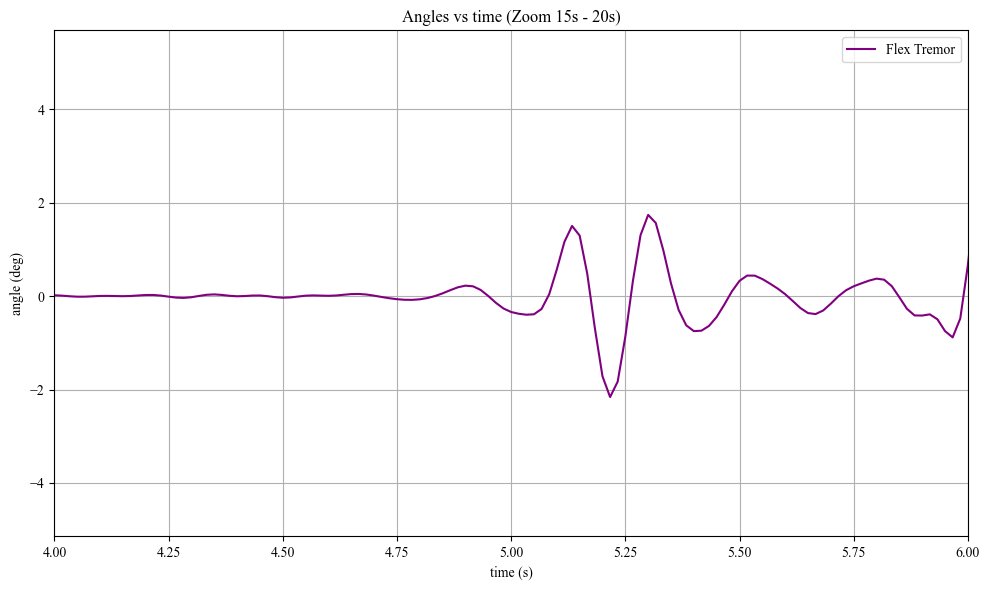

In [322]:
time, flex_tremor, joint_flex = main(file_name)

plt.figure(figsize=(10, 6))
plt.plot(time, flex_tremor, label="Flex Tremor", color="purple")

# --- AQUÍ SE APLICA EL ZOOM ---
plt.xlim(4, 6)  # Limita el eje X entre 11 y 16 segundos
# ------------------------------

plt.title("Angles vs time (Zoom 15s - 20s)")
plt.xlabel("time (s)")
plt.ylabel("angle (deg)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [323]:

flex_tremor= flex_tremor[301:]
time = time[301:]

len_flex_tremor = len(flex_tremor)
print("length of flex tremor after trigger:", len_flex_tremor)

length of flex tremor after trigger: 4929


lengths ECR FCR t: 204000 204000 204000


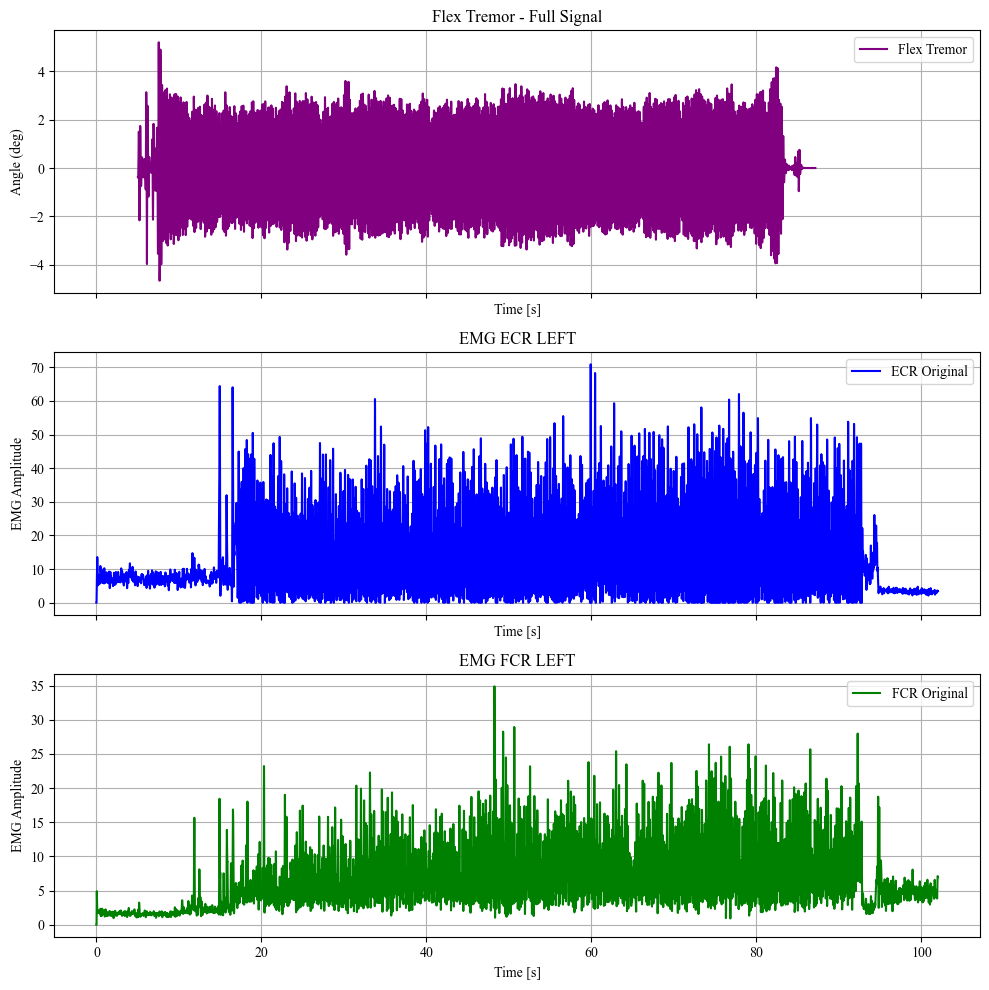

In [324]:
    # 2. Extraer las variables guardadas
ECR = mat["ECR_final"].flatten()
FCR = mat["FCR_final"].flatten()
t   = mat["t_sync"].flatten()


print("lengths ECR FCR t:" , len(ECR), len(FCR), len(t))
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

# --- 0. flex_tremor vs time ---
axes[0].plot(time, flex_tremor, label='Flex Tremor', color='purple')
axes[0].set_xlabel('Time [s]')
axes[0].set_ylabel('Angle (deg)')
axes[0].set_title('Flex Tremor - Full Signal')
axes[0].legend()
axes[0].grid(True)

# --- 1. ECR vs t ---
axes[1].plot(t, ECR, label='ECR Original', color='blue')
axes[1].set_xlabel('Time [s]')
axes[1].set_ylabel('EMG Amplitude')
axes[1].set_title('EMG ECR LEFT')
axes[1].legend()
axes[1].grid(True)

    # --- 2. FCR vs t ---
axes[2].plot(t, FCR, label='FCR Original', color='green')
axes[2].set_xlabel('Time [s]')
axes[2].set_ylabel('EMG Amplitude')
axes[2].set_title('EMG FCR LEFT')
axes[2].legend()
axes[2].grid(True)
plt.tight_layout()

lengths recortados: 174548 174548


C:\Users\adria\AppData\Local\Temp\ipykernel_45872\1057637607.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()
C:\Users\adria\AppData\Local\Temp\ipykernel_45872\1057637607.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


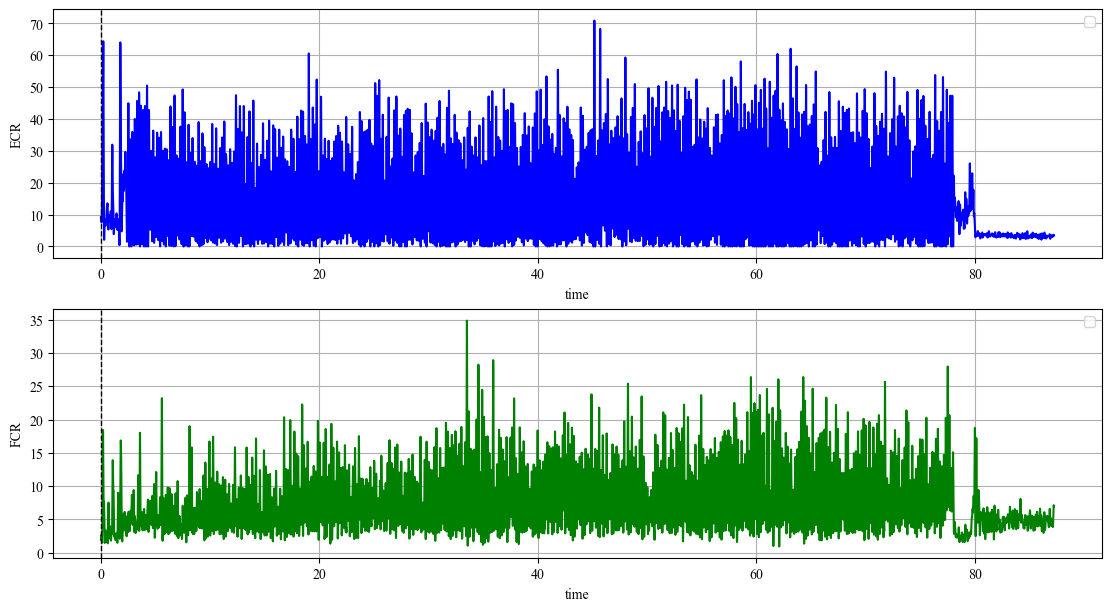

In [325]:
    #Recorte señales EMG:
trigger= 29452
ECR_recortado= ECR[trigger:]
FCR_recortado= FCR[trigger:]
print("lengths recortados:" , len(ECR_recortado), len(FCR_recortado))
t_recortado= t[:174548] #141000 es el numero de muestras que quedan despues del trigger, lo calculo con el tiempo del wrist que es 141000/60=2350s a 60Hz y me da el numero de muestras totales que tengo que recortar para quedarme solo con las muestras del wrist



fig, axes = plt.subplots(2, 1, figsize=(11, 6), constrained_layout=True)

axes[0].plot(t_recortado, ECR_recortado, color="blue", linewidth=1.5)
axes[0].axvline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_xlabel("time")
axes[0].set_ylabel("ECR")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(t_recortado, FCR_recortado, color="green", linewidth=1.5)
axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_xlabel("time")
axes[1].set_ylabel("FCR")
axes[1].legend()
axes[1].grid(True)

length ECR downsampled: 4929
length FCR downsampled: 4929


C:\Users\adria\AppData\Local\Temp\ipykernel_45872\2603383731.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()
C:\Users\adria\AppData\Local\Temp\ipykernel_45872\2603383731.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


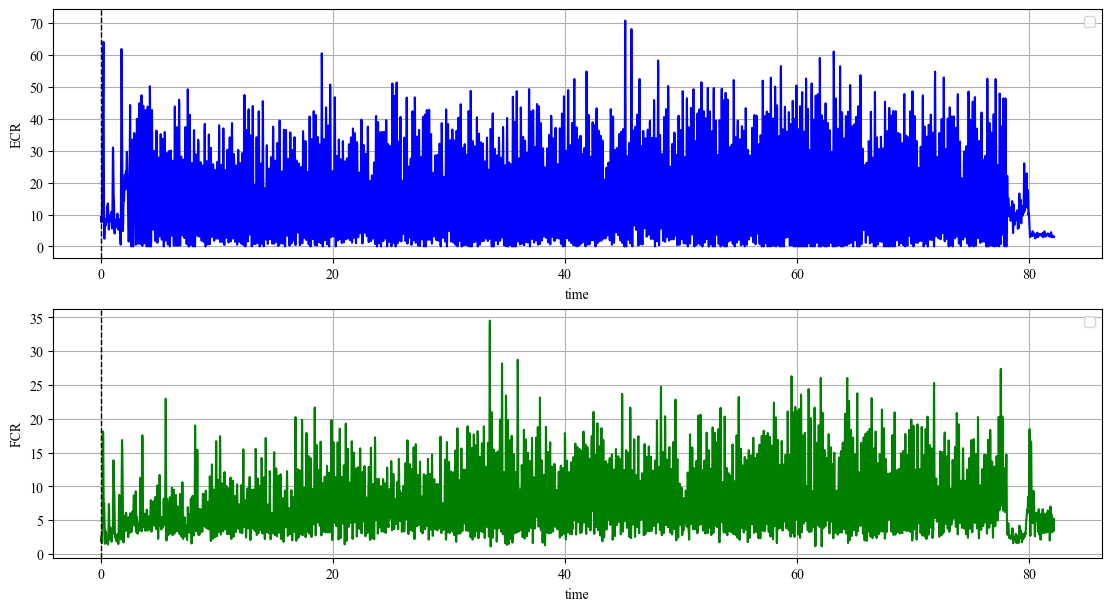

In [326]:
#esta es la longitud real de la señal EMG; y se hace downsample a 60 Hz pero con su tiempo real. 
t_start  = 0 
t_end  =  4929/60 #77.208 es el tiempo total del wrist despues del trigger, lo calculo con el numero de muestras que quedan despues del trigger (154416) dividido por la frecuencia de muestreo (60Hz)
time_emg = np.arange(t_start, t_end, 1/60)  # vector a 60 Hz
# Interpolar a los tiempos del wrist
ECR_downsampled = np.interp(time_emg, t_recortado, ECR_recortado)
FCR_downsampled = np.interp(time_emg, t_recortado, FCR_recortado)

print("length ECR downsampled:", len(ECR_downsampled))
print("length FCR downsampled:", len(FCR_downsampled))

fig, axes = plt.subplots(2, 1, figsize=(11, 6), constrained_layout=True)

axes[0].plot(time_emg, ECR_downsampled, color="blue", linewidth=1.5)
axes[0].axvline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_xlabel("time")
axes[0].set_ylabel("ECR")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(time_emg, FCR_downsampled, color="green", linewidth=1.5)
axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_xlabel("time")
axes[1].set_ylabel("FCR")
axes[1].legend()
axes[1].grid(True)

In [327]:
flex_tremor= flex_tremor[:]
len_flex_tremor = len(flex_tremor)
print("length of flex tremor after trigger:", len_flex_tremor)

length of flex tremor after trigger: 4929


length ECR final: 4929
length FCR final: 4929
length time final: 4929
length flex tremor final: 4929


C:\Users\adria\AppData\Local\Temp\ipykernel_45872\2610371939.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()
C:\Users\adria\AppData\Local\Temp\ipykernel_45872\2610371939.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()
C:\Users\adria\AppData\Local\Temp\ipykernel_45872\2610371939.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[2].legend()


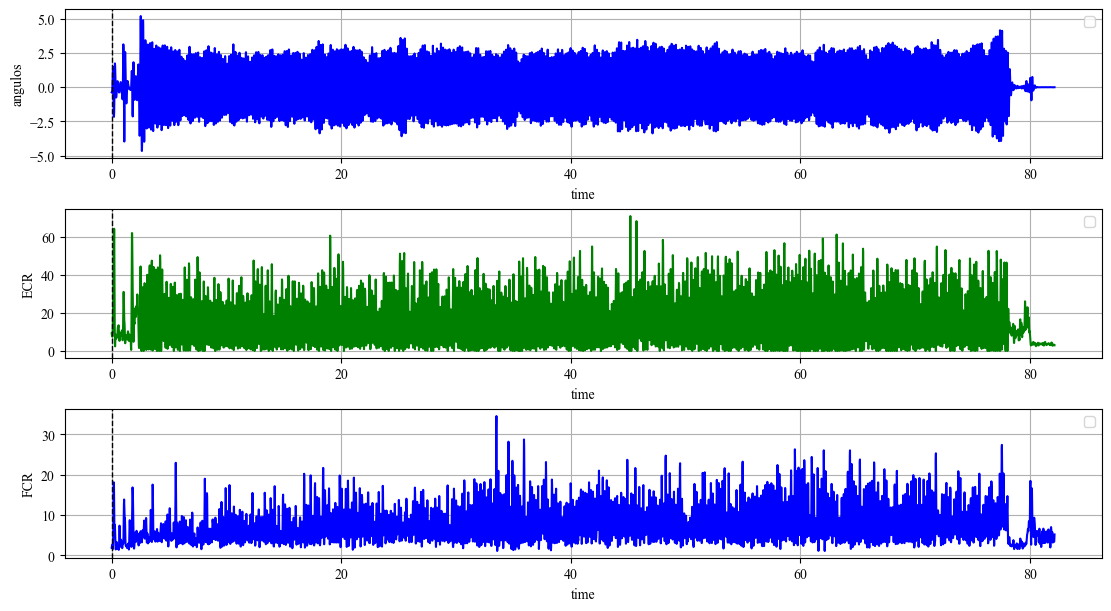

In [328]:
ECR_final= ECR_downsampled[:]
FCR_final= FCR_downsampled[:]
fs = 60  # Frecuencia de muestreo (Hz)
num_muestras = 4718# Número exacto de muestras que quieres

# El límite superior de arange será num_muestras * (1/fs)
time=time_emg[:]
flex_tremor= flex_tremor[:]

print("length ECR final:", len(ECR_final))
print("length FCR final:", len(FCR_final))
print("length time final:", len(time))
print("length flex tremor final:", len(flex_tremor))

fig, axes = plt.subplots(3, 1, figsize=(11, 6), constrained_layout=True)

axes[0].plot(time, flex_tremor, color="blue", linewidth=1.5)
axes[0].axvline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_xlabel("time")
axes[0].set_ylabel("angulos")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(time, ECR_final, color="green", linewidth=1.5)
axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_xlabel("time")
axes[1].set_ylabel("ECR")
axes[1].legend()
axes[1].grid(True)

axes[2].plot(time, FCR_final, color="blue", linewidth=1.5)
axes[2].axvline(0, color="black", linestyle="--", linewidth=1)
axes[2].set_xlabel("time")
axes[2].set_ylabel("FCR")
axes[2].legend()
axes[2].grid(True)



plt.show() 

C:\Users\adria\AppData\Local\Temp\ipykernel_45872\1269014329.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()
C:\Users\adria\AppData\Local\Temp\ipykernel_45872\1269014329.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()
C:\Users\adria\AppData\Local\Temp\ipykernel_45872\1269014329.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[2].legend()


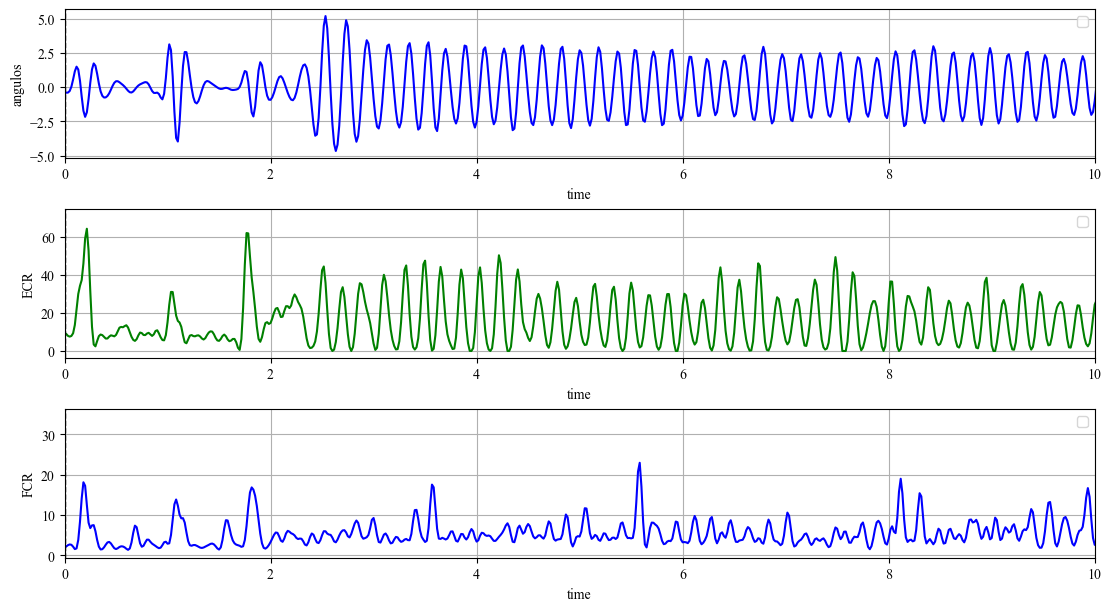

In [329]:
fig, axes = plt.subplots(3, 1, figsize=(11, 6), constrained_layout=True)

axes[0].plot(time, flex_tremor, color="blue", linewidth=1.5)
axes[0].axvline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_xlabel("time")
axes[0].set_ylabel("angulos")
axes[0].legend()
axes[0].grid(True)
axes[0].set_xlim(0, 10)

axes[1].plot(time, ECR_final, color="green", linewidth=1.5)
axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_xlabel("time")
axes[1].set_ylabel("ECR")
axes[1].legend()
axes[1].grid(True)
axes[1].set_xlim(0, 10)

axes[2].plot(time, FCR_final, color="blue", linewidth=1.5)
axes[2].axvline(0, color="black", linestyle="--", linewidth=1)
axes[2].set_xlabel("time")
axes[2].set_ylabel("FCR")
axes[2].legend()
axes[2].grid(True)
axes[2].set_xlim(0, 10)

plt.show()

C:\Users\adria\AppData\Local\Temp\ipykernel_45872\3140158363.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()
C:\Users\adria\AppData\Local\Temp\ipykernel_45872\3140158363.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()
C:\Users\adria\AppData\Local\Temp\ipykernel_45872\3140158363.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[2].legend()


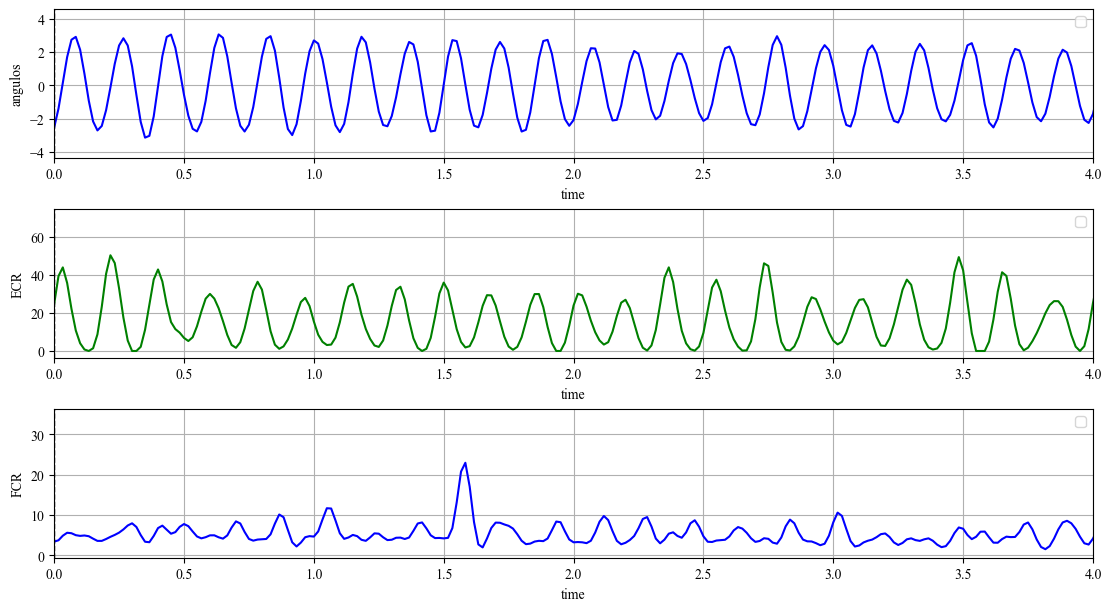

In [330]:
ECR_final=ECR_final[240:]
FCR_final=FCR_final[240:]
flex_tremor=flex_tremor[240:]
time=time[:4689]

fig, axes = plt.subplots(3, 1, figsize=(11, 6), constrained_layout=True)


axes[0].plot(time, flex_tremor, color="blue", linewidth=1.5)
axes[0].axvline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_xlabel("time")
axes[0].set_ylabel("angulos")
axes[0].legend()
axes[0].grid(True)
axes[0].set_xlim(0, 4)

axes[1].plot(time, ECR_final, color="green", linewidth=1.5)
axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_xlabel("time")
axes[1].set_ylabel("ECR")
axes[1].legend()
axes[1].grid(True)
axes[1].set_xlim(0, 4)

axes[2].plot(time, FCR_final, color="blue", linewidth=1.5)
axes[2].axvline(0, color="black", linestyle="--", linewidth=1)
axes[2].set_xlabel("time")
axes[2].set_ylabel("FCR")
axes[2].legend()
axes[2].grid(True)
axes[2].set_xlim(0, 4)

plt.show()

In [331]:
ECR_act=ECR_final[:]
FCR_act=FCR_final[:]
wrist_hand_r3_pos=flex_tremor[:]

datos = np.column_stack((
    ECR_act, 
    FCR_act, 
    wrist_hand_r3_pos
))

np.savetxt(
    "C:/Users/adria/Downloads/Python-IMU/Adriana-Neuroengineering_lab/20260525/EMG_matlab/20260525_subject_01_cond_ASS-PRE-EXT-RIGHT_run_04_ecr_fcr_final.csv",
    datos,
    delimiter=",",
    header="ECR_act,FCR_act,wrist_hand_r3_pos",
    comments="",       # para que no ponga '#' delante del header
    fmt="%.6f"         # formato de números (6 decimales)
)

print("Archivo guardado correctamente :)")
print("length:", len(datos))


Archivo guardado correctamente :)
length: 4689
